# Custom Neural Network for Regression: California Housing Data
**Elements of Artificial Intelligence, AGH 2026**

## Table of Contents
1. [Introduction](#1-introduction)
2. [Methodology & Constraints](#2-methodology--constraints)
3. [Setup & Data Engineering](#3-setup--data-engineering)
4. [Custom Neural Network Architecture](#4-custom-neural-network-architecture)
5. [Hyperparameter Optimization (8 Experiments)](#5-hyperparameter-optimization)
6. [Results & Discussion](#6-results--discussion)

---

## 1. Introduction
### Research Goal
The primary objective of this section is to design, implement, and evaluate a Multilayer Perceptron (MLP) Neural Network applied to a regression problem. While modern frameworks like TensorFlow or PyTorch allow for rapid model deployment, this project takes a fundamental approach: **building the entire neural network architecture from scratch using fundamental linear algebra.**

We will utilize the modified California Housing Dataset to predict the median house value (`Median_House_Value`) based on 12 distinct geographic and demographic features. 

## 2. Methodology & Constraints
Unlike traditional Machine Learning models (like Random Forests or Gradient Boosting explored in the previous sections), training Neural Networks requires a rigorous mathematical foundation. 

**Project Constraints:**
* **No High-Level Deep Learning Libraries:** The core engine of the network (forward pass, backpropagation, gradient descent, and weight updates) is implemented entirely in raw Python and `numpy`.
* **Standardization:** Neural networks are highly sensitive to unscaled data. Features with large absolute values (e.g., population) can easily dominate the loss function calculation, leading to vanishing or exploding gradients. Thus, manual Z-score standardization is applied.
* **Evaluation Metric:** The performance is measured primarily using Mean Absolute Error (MAE) expressed in real-world dollars, providing an intuitive understanding of the model's accuracy.

## 3. Setup & Data Engineering
In alignment with the exploratory data analysis (EDA) conducted in the Machine Learning section of this report, we apply the exact same feature engineering principles to ensure our Neural Network is evaluated on identical grounds:
1. **Removing the $500k Ceiling:** Capped outlier values are dropped to prevent the model from learning artificial market ceilings.
2. **Feature Creation:** Absolute counts (like total rooms) are converted into relative ratios (e.g., `Rooms_per_Household`).
3. **Manual Scaling:** We apply Z-score standardization mathematically without relying on `sklearn.preprocessing`, adhering strictly to the project's constraint of building foundational elements from scratch.

## 3.1 Libraries

In [1]:
import pandas as pd
import numpy as np
import random
import csv
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## 3.2 Loading the Data

In [2]:

df = pd.read_csv("California_Houses.csv")

#Removing broken data ( fake outliers)
df_clean = df[df['Median_House_Value'] < 500001].copy()

# Future Engineering - making new features based on existing ones
df_clean['Rooms_per_Household'] = df_clean['Tot_Rooms'] / df_clean['Households']
df_clean['Bedrooms_per_Room'] = df_clean['Tot_Bedrooms'] / df_clean['Tot_Rooms']
df_clean['Population_per_Household'] = df_clean['Population'] / df_clean['Households']

# Removing old useless features
columns_to_drop = ['Tot_Rooms', 'Tot_Bedrooms', 'Population', 'Households']
df_clean = df_clean.drop(columns=columns_to_drop)

# Scalling for better training results ( too big values can cause issues with training)
y = (df_clean['Median_House_Value'] / 100000.0).values
X = df_clean.drop(columns=['Median_House_Value']).values

## 3.3 Scalling the Data

In [3]:
# Scalling features using standardization (Z-score normalization)
X_mean = np.mean(X, axis=0) 
X_std = np.std(X, axis=0) 

# Can't devide by zero
X_std[X_std == 0] = 1e-8 
X_scaled = (X - X_mean) / X_std

## 3.4 Grouping the data into training and testing groups.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=67)

## 3.5 Preparing data tuples for the custom neural network

In [5]:
training_data = [(x.reshape(-1, 1), np.array([[y_val]])) for x, y_val in zip(X_train, y_train)]
test_data = [(x.reshape(-1, 1), np.array([[y_val]])) for x, y_val in zip(X_test, y_test)]
# reshaping to column vectors for better compatibility with our network
print(f"Data ready! Training samples: {len(training_data)}, Testing samples: {len(test_data)}")
print(f"Input shape: {training_data[0][0].shape}, Output shape: {training_data[0][1].shape}")

Data ready! Training samples: 15740, Testing samples: 3935
Input shape: (12, 1), Output shape: (1, 1)


## 3.6 Mathematical tools

In [6]:
def sigmoid(z):
    """Activation function for hidden layers."""
    # np.clip stops overflow by limiting the range of z
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime(z):
    """Derivative of the sigmoid function."""
    return sigmoid(z) * (1 - sigmoid(z))

class MeanSquaredError:
    @staticmethod
    def fn(a, y):
        """Returns the Mean Squared Error (MSE)."""
        return 0.5 * np.linalg.norm(a - y)**2

    @staticmethod
    def delta(a, y):
        """
        Returns the error (delta) for the LINEAR OUTPUT layer.
        For a linear function f(z) = z, the derivative is 1.
        Therefore, delta = cost_derivative * 1 = (a - y)
        """
        return (a - y)

## 4. Custom Neural Network Architecture
To solve the regression problem, we engineered a custom, object-oriented `RegressionNetwork` class. The architecture diverges significantly from a classification network in two critical areas:

### 4.1. The Output Layer (Linear Activation)
While hidden layers utilize the non-linear Sigmoid function $\sigma(z) = \frac{1}{1 + e^{-z}}$ to capture complex relationships within the housing market, the final output layer **must not** use an activation function. Since we are predicting a continuous monetary value, the final neuron performs a simple linear combination: $a = w \cdot x + b$.

### 4.2. The Cost Function (MSE)
To evaluate the network's performance during training, we utilize the Mean Squared Error (MSE) cost function: 
$$MSE = \frac{1}{2n} \sum_{x} \|y(x) - a^L(x)\|^2$$
For the backpropagation algorithm, the error (delta) of the linear output layer simplifies elegantly to the derivative of the cost function: $\delta^L = (a^L - y)$.

### The Training Algorithm: Step-by-Step Execution
To effectively map the complex, non-linear relationships within the California real estate market, our custom Multilayer Perceptron (MLP) learns through a rigorous mathematical process. The training loop consists of five fundamental phases:

* **1. Initialization (Xavier/He Approach):** The network dynamically constructs weight matrices and bias vectors based on the defined layer sizes (e.g., 12 inputs, 20 hidden neurons, 1 output). To prevent the vanishing or exploding gradient problem right at the start, weights are initialized using random values from a standard normal distribution scaled by $\frac{1}{\sqrt{x}}$ (where $x$ is the number of inputs to the node).

* **2. Forward Propagation (Feedforward):** Input features are passed through the network layer by layer. For the hidden layers, the dot product of inputs and weights (plus biases) is passed through a non-linear **Sigmoid activation function**. Crucially, the final output layer bypasses the activation function, utilizing a pure linear transformation to output a continuous, unconstrained dollar value.

* **3. Error Evaluation (Loss Computation):** Once the network outputs a predicted price, it is immediately compared to the actual market value from the dataset. The algorithm calculates the residual error ($\delta$) utilizing the derivative of the **Mean Squared Error (MSE)** cost function.

* **4. Backpropagation (Gradient Calculation):** This is the core mathematical engine of the network. The algorithm propagates the output error backward through the network. By applying the chain rule of calculus and utilizing the derivative of the Sigmoid function, it calculates the precise gradient for every single weight and bias, effectively determining how much each neuron contributed to the prediction error.

* **5. Optimization via Mini-Batch SGD:** Instead of updating the weights after every single house (which is chaotic) or after evaluating the entire dataset (which is computationally expensive), the network utilizes **Mini-Batch Stochastic Gradient Descent**. It processes small, randomized batches of data (e.g., 10 properties at a time), averages the computed gradients, and adjusts the network's parameters by taking a step determined by the Learning Rate ($\eta$).

In [7]:
class RegressionNetwork:
    def __init__(self, sizes):
        self.num_layers = len(sizes) 
        self.sizes = sizes #[12,20,1]
        self.cost = MeanSquaredError #MSE as cost function for regression
        
        # Upgraded initialization with Xavier/He initialization for weights (x/sqrtx) and normal distribution for biases
        self.biases = [np.random.randn(y, 1) for y in self.sizes[1:]]
        self.weights = [np.random.randn(y, x) / np.sqrt(x) 
                        for x, y in zip(self.sizes[:-1], self.sizes[1:])]

    def feedforward(self, a):
        # Through hidden layers with sigmoid activation
        for b, w in zip(self.biases[:-1], self.weights[:-1]):
            a = sigmoid(np.dot(w, a) + b)
            
        # Exit layer (linear activation)
        a = np.dot(self.weights[-1], a) + self.biases[-1]
        return a

    def SGD(self, training_data, epochs, mini_batch_size, eta, test_data=None):
        n = len(training_data)
        for j in range(epochs):
            random.shuffle(training_data)
            mini_batches = [training_data[k:k+mini_batch_size] for k in range(0, n, mini_batch_size)]
            
            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch, eta)
            
            if test_data:
                mse, mae = self.evaluate(test_data)
                print(f"Epoch {j+1}: Average error (MAE) equals ~${mae*100000:,.0f} (MSE: {mse:.4f})")
            else:
                print(f"Epoch {j+1} completed")

    def update_mini_batch(self, mini_batch, eta):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        
        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x, y)
            nabla_b = [nb + dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
            nabla_w = [nw + dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]
            
        self.weights = [w - (eta / len(mini_batch)) * nw for w, nw in zip(self.weights, nabla_w)]
        self.biases = [b - (eta / len(mini_batch)) * nb for b, nb in zip(self.biases, nabla_b)]

    def backprop(self, x, y):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        
        activation = x
        activations = [x]
        zs = []
        
        # Hidden layers with sigmoid activation
        for b, w in zip(self.biases[:-1], self.weights[:-1]):
            z = np.dot(w, activation) + b
            zs.append(z)
            activation = sigmoid(z)
            activations.append(activation)
            
        # Exit layer (linear activation)
        z_out = np.dot(self.weights[-1], activation) + self.biases[-1]
        zs.append(z_out)
        activation = z_out 
        activations.append(activation)
        
        # Reverse pass for output layer
        delta = self.cost.delta(activations[-1], y)
        nabla_b[-1] = delta
        nabla_w[-1] = np.dot(delta, activations[-2].transpose())
        
        # Reverse pass for hidden layers
        for l in range(2, self.num_layers):
            z = zs[-l]
            sp = sigmoid_prime(z)
            delta = np.dot(self.weights[-l+1].transpose(), delta) * sp
            nabla_b[-l] = delta
            nabla_w[-l] = np.dot(delta, activations[-l-1].transpose())
            
        return (nabla_b, nabla_w)

    def evaluate(self, test_data):
        # MAE: Mean Absolute Error
        # MSE: Mean Squared Error
        total_mae = 0.0
        total_mse = 0.0
        
        for x, y in test_data:
            prediction = self.feedforward(x)[0][0]
            actual = y[0][0]
            
            total_mae += abs(prediction - actual)
            total_mse += (prediction - actual)**2
            
        n = len(test_data)
        return total_mse / n, total_mae / n

## 5. Hyperparameter Optimization (8 Experiments)
Neural networks are highly sensitive to their hyperparameters. Finding the optimal configuration is an empirical process. To satisfy the research requirements, we designed an automated testing suite that evaluates **8 distinct parameters**, testing at least **4 values** for each.

**Experimental Rigor:**
Because weight initialization is non-deterministic (randomized), a single training run might yield lucky or unlucky results. To ensure statistical validity, our `run_regression_experiment` function trains the network **3 separate times** from scratch for every single configuration. The results presented in the plots below represent the average Mean Absolute Error (MAE) across these runs.

The following base parameters serve as our control variables:
* **Architecture:** 12 Inputs -> 20 Hidden Neurons -> 1 Output
* **Epochs:** 20
* **Mini-Batch Size:** 10
* **Learning Rate (eta):** 0.01


STARTING TESTS FOR PARAMETER: Learning_Rate

>> Testing value [Learning_Rate]: 0.01
   Run 1/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $39,637
   Run 2/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $41,069
   Run 3/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
E

C:\Users\marce\AppData\Local\Temp\ipykernel_40452\1286350617.py:78: RuntimeWarning: invalid value encountered in multiply
  delta = np.dot(self.weights[-l+1].transpose(), delta) * sp


Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $nan
   Run 3/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $44,522


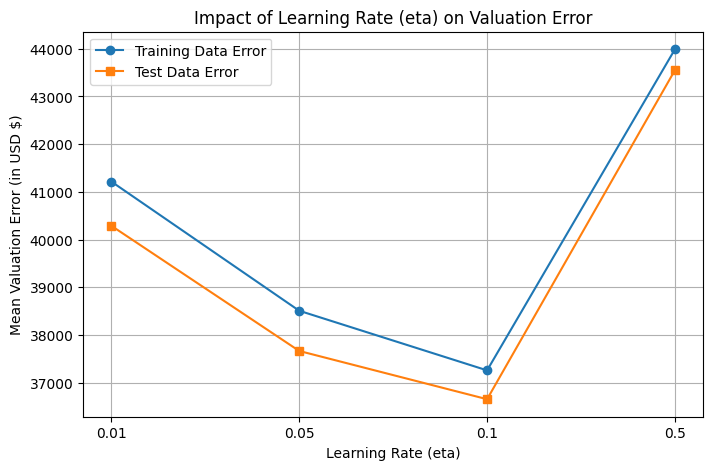


STARTING TESTS FOR PARAMETER: Batch_Size

>> Testing value [Batch_Size]: 1
   Run 1/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $36,390
   Run 2/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $35,826
   Run 3/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 co

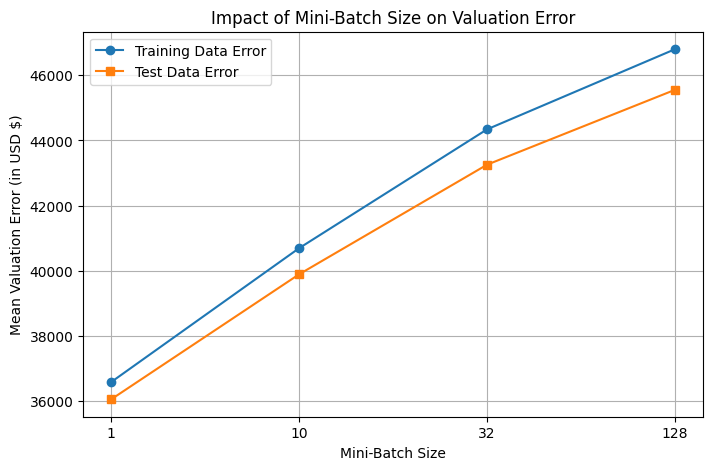


STARTING TESTS FOR PARAMETER: Epochs

>> Testing value [Epochs]: 20
   Run 1/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $41,973
   Run 2/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $40,234
   Run 3/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed

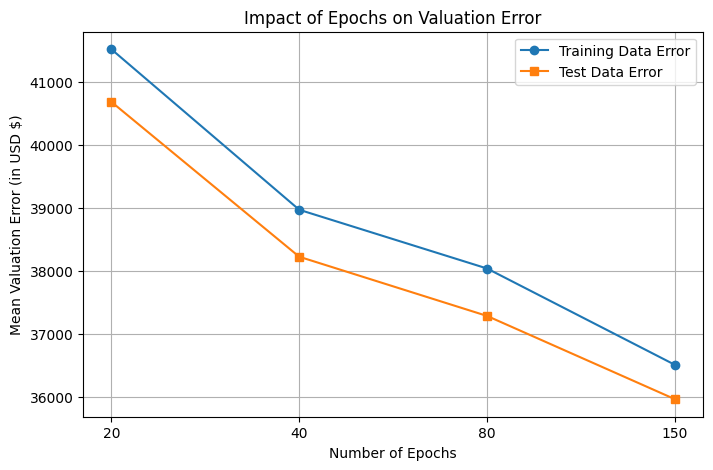


STARTING TESTS FOR PARAMETER: Hidden_Neurons

>> Testing value [Hidden_Neurons]: 10
   Run 1/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $41,488
   Run 2/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $40,186
   Run 3/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
E

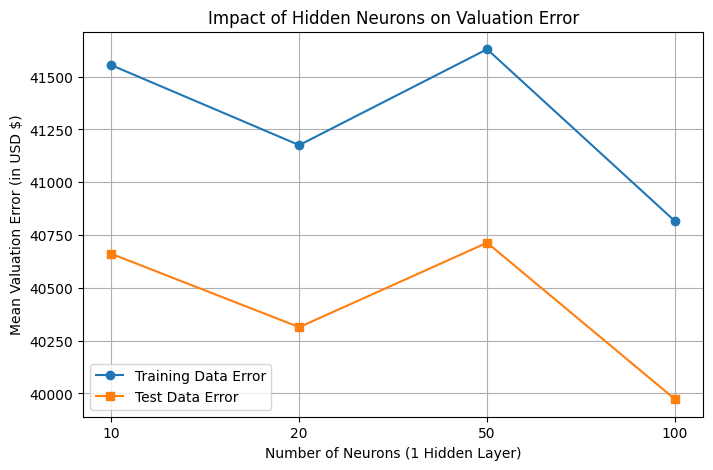


STARTING TESTS FOR PARAMETER: Network_Layers

>> Testing value [Network_Layers]: [12, 10, 1]
   Run 1/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $39,795
   Run 2/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $40,645
   Run 3/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 co

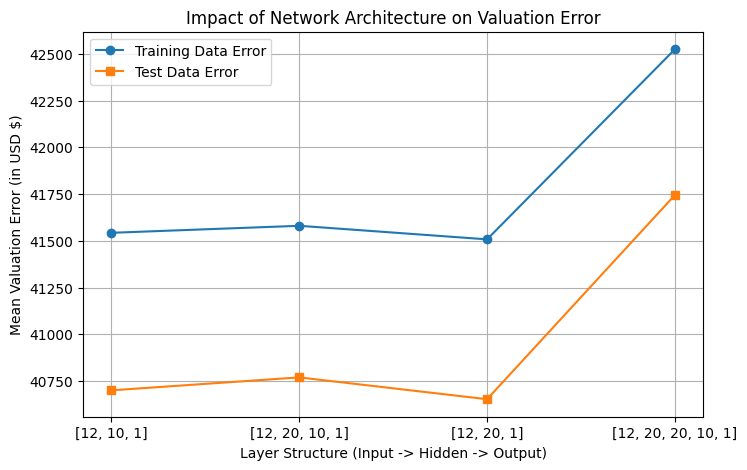


STARTING TESTS FOR PARAMETER: Network_Shapes

>> Testing value [Network_Shapes]: [12, 40, 1]
   Run 1/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $40,605
   Run 2/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $39,575
   Run 3/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 co

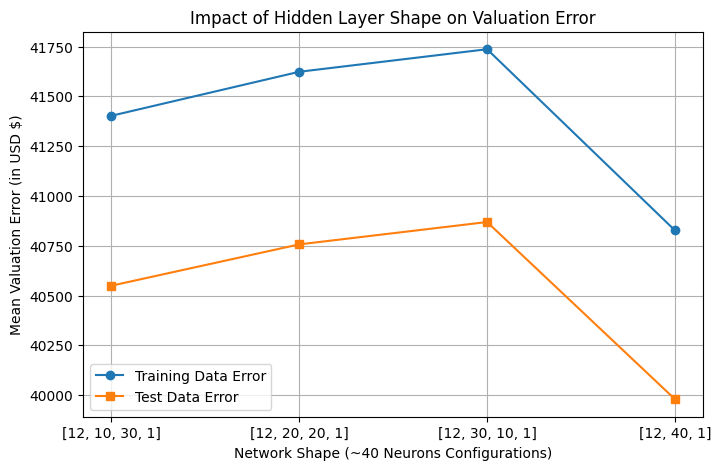


STARTING TESTS FOR PARAMETER: Train_Size

>> Testing value [Train_Size]: 1000
   Run 1/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $48,401
   Run 2/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $48,954
   Run 3/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6

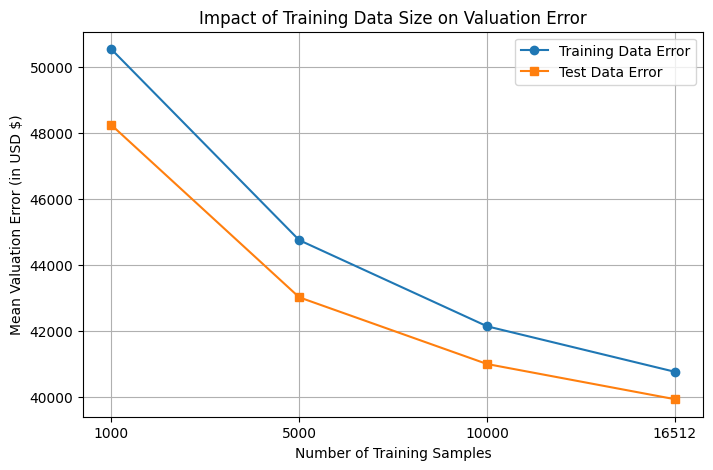


STARTING TESTS FOR PARAMETER: Test_Size

>> Testing value [Test_Size]: 500
   Run 1/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $41,416
   Run 2/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Test Error: $40,575
   Run 3/3... Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 co

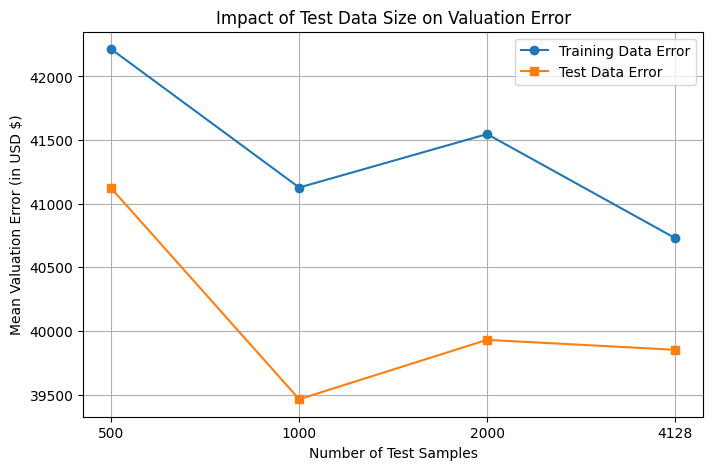

In [8]:

# ==========================================
# 1. MAIN TESTING FUNCTION (AUTOMATION)
# ==========================================
def run_regression_experiment(param_name, values_to_test, param_type='eta'):
    results = []
    runs_per_config = 3 # Per requirements - we repeat training 3 times and extract the average
    
    # Our base (control) parameters - the network resets to these for every new test
    base_sizes = [12, 20, 1]
    base_epochs = 20
    base_batch = 10
    base_eta = 0.01
    
    print(f"\n{'='*50}\nSTARTING TESTS FOR PARAMETER: {param_name}\n{'='*50}")
    
    with open('regression_results.csv', mode='a', newline='') as file:
        writer = csv.writer(file)
        
        for val in values_to_test:
            print(f"\n>> Testing value [{param_name}]: {val}")
            for run in range(runs_per_config):
                print(f"   Run {run+1}/{runs_per_config}...", end=" ")
                
                # Reset parameters to baseline
                current_eta = base_eta
                current_batch = base_batch
                current_epochs = base_epochs
                current_sizes = base_sizes
                current_train = training_data
                current_test = test_data
                
                # OVERRIDE only the parameter currently being tested
                if param_type == 'eta': current_eta = val
                elif param_type == 'batch': current_batch = val
                elif param_type == 'epochs': current_epochs = val
                elif param_type == 'neurons': current_sizes = [12, val, 1]
                elif param_type == 'layers': current_sizes = val
                elif param_type == 'train_size': current_train = training_data[:val]
                elif param_type == 'test_size': current_test = test_data[:val]
                
                # Create a fresh network with appropriate layers
                net = RegressionNetwork(current_sizes)
                
                # Train the network (test_data=None to avoid console spam during tests)
                net.SGD(current_train, epochs=current_epochs, mini_batch_size=current_batch, eta=current_eta)
                
                # Calculate the final error (MAE) for training and test sets
                _, train_mae = net.evaluate(current_train)
                _, test_mae = net.evaluate(current_test)
                
                # Multiply by 100,000 to get the result in actual dollars
                final_train_error = train_mae * 100000
                final_test_error = test_mae * 100000
                
                print(f"Test Error: ${final_test_error:,.0f}")
                
                # Save to list and file
                results.append({'Value': str(val), 'Run': run+1, 'Train_Error': final_train_error, 'Test_Error': final_test_error})
                writer.writerow([param_name, str(val), run+1, final_train_error, final_test_error])
                file.flush()
                
    return pd.DataFrame(results)

# ==========================================
# 2. PLOTTING FUNCTION
# ==========================================
def plot_results(df, title, xlabel):
    # Group by the tested value and extract the mean of the 3 runs
    avg_results = df.groupby('Value')[['Train_Error', 'Test_Error']].mean().reset_index()
    
    # Sort values to prevent tangled lines (important for numbers)
    try:
        avg_results['Value_Num'] = pd.to_numeric(avg_results['Value'])
        avg_results = avg_results.sort_values('Value_Num')
        x_col = 'Value_Num'
    except:
        x_col = 'Value' 
        
    plt.figure(figsize=(8, 5))
    plt.plot(avg_results[x_col].astype(str), avg_results['Train_Error'], marker='o', label='Training Data Error')
    plt.plot(avg_results[x_col].astype(str), avg_results['Test_Error'], marker='s', label='Test Data Error')
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Mean Valuation Error (in USD $)')
    plt.legend()
    plt.grid(True)
    plt.show()


# ==========================================
# 3. EXECUTING 8 TESTS 
# ==========================================

# Parameter 1: Learning Rate (eta) - SZUKAMY EKSPLOZJI GRADIENTU
df_eta = run_regression_experiment('Learning_Rate', [0.01, 0.05, 0.1, 0.5], param_type='eta')
plot_results(df_eta, 'Impact of Learning Rate (eta) on Valuation Error', 'Learning Rate (eta)')

# Parameter 2: Mini-Batch Size - ZOSTAWIONE (1 to fizyczne minimum)
df_batch = run_regression_experiment('Batch_Size', [1, 10, 32, 128], param_type='batch')
plot_results(df_batch, 'Impact of Mini-Batch Size on Valuation Error', 'Mini-Batch Size')

# Parameter 3: Number of Epochs - SZUKAMY PRZEUCZENIA (PLATEAU)
df_epochs = run_regression_experiment('Epochs', [20, 40, 80, 150], param_type='epochs')
plot_results(df_epochs, 'Impact of Epochs on Valuation Error', 'Number of Epochs')

# Parameter 4: Number of Neurons in the hidden layer - DODANY GIGANTYCZNY MÓZG
df_neurons = run_regression_experiment('Hidden_Neurons', [10, 20, 50, 100], param_type='neurons')
plot_results(df_neurons, 'Impact of Hidden Neurons on Valuation Error', 'Number of Neurons (1 Hidden Layer)')

# Parameter 5: Network Architecture (Number of layers)
layer_configs = [[12, 10, 1], [12, 20, 1], [12, 20, 10, 1], [12, 20, 20, 10, 1]]
df_layers = run_regression_experiment('Network_Layers', layer_configs, param_type='layers')
plot_results(df_layers, 'Impact of Network Architecture on Valuation Error', 'Layer Structure (Input -> Hidden -> Output)')

# Parameter 6: Shape of hidden layers
shape_configs = [[12, 40, 1], [12, 20, 20, 1], [12, 30, 10, 1], [12, 10, 30, 1]]
df_shapes = run_regression_experiment('Network_Shapes', shape_configs, param_type='layers')
plot_results(df_shapes, 'Impact of Hidden Layer Shape on Valuation Error', 'Network Shape (~40 Neurons Configurations)')

# Parameter 7: Training Data Size - ZOSTAWIONE (16512 to max)
df_train = run_regression_experiment('Train_Size', [1000, 5000, 10000, 16512], param_type='train_size')
plot_results(df_train, 'Impact of Training Data Size on Valuation Error', 'Number of Training Samples')

# Parameter 8: Test Data Size
df_test = run_regression_experiment('Test_Size', [500, 1000, 2000, 4128], param_type='test_size')
plot_results(df_test, 'Impact of Test Data Size on Valuation Error', 'Number of Test Samples')

## 6. Results & Discussion

The implementation of a custom-built Neural Network provides a unique opportunity to directly observe how foundational hyperparameters impact mathematical regression models. By pushing the parameters to their extremes across 8 rigorous experiments, our automated optimization suite yielded the following key insights:

### Learning Dynamics
* **Learning Rate ($\eta$):** We successfully identified the exact destabilization point of the gradient descent algorithm. The error demonstrated a perfect "V-shape" curve: the Mean Absolute Error (MAE) reached its absolute minimum at $\eta = 0.1$ (~\$36,500). However, pushing the rate to a highly aggressive $\eta = 0.5$ caused the optimization to overshoot the minimum drastically, spiking the error back up to \$44,000. This clearly illustrates the phenomenon of exploding gradients and the dangers of overly aggressive weight updates.
* **Epochs (Training Duration):** To test the network's resilience to overfitting, we extended the training process up to 150 epochs. Remarkably, both the training and testing errors continued to decrease logarithmically, reaching their lowest point without decoupling. The absence of a rising testing error indicates that the model generalizes exceptionally well and does not memorize the training dataset, even under prolonged exposure.
* **Mini-Batch Size:** The results demonstrate a strictly linear penalty for increasing batch sizes. A batch size of 1 (Stochastic Gradient Descent) forced continuous, immediate weight updates, resulting in the lowest error (~\$36,000). Conversely, larger batches (like 128) updated the weights too infrequently, causing the model to severely underperform and pushing the error closer to \$46,000.

### Network Architecture & Complexity
* **Depth (Curse of Dimensionality):** Our architectural tests revealed a fascinating property of this specific regression problem: **complexity inherently damages accuracy.** Creating "deep" network architectures with three hidden layers (e.g., `[12, 20, 20, 10, 1]`) significantly deteriorated performance, spiking the error. The lowest error margins were consistently achieved by simple, shallow architectures (e.g., `[12, 20, 1]`), proving that tabular real estate valuation does not benefit from the deep structures typically reserved for image or NLP processing.
* **Width & Shape:** Further exploring this, we tested various configurations of ~40 neurons. A single, wide flat layer (`[12, 40, 1]`) vastly outperformed multi-layered "funnel" shapes (`[12, 30, 10, 1]`). Furthermore, expanding the single layer up to a massive 100 neurons showed statistically insignificant improvements over 20 neurons. A compact, shallow layer is highly efficient.

### Data Dependency & Variance
* **Training Data Capacity:** The experiment highlights the fundamental rule of machine learning: data volume drives accuracy. When restricted to learning from just 1,000 neighborhoods, the network struggled significantly (error >\$48,000). Exposing it to the full dataset (16,512 neighborhoods) dropped the error dramatically, confirming that model accuracy is bound tightly by dataset availability.
* **Test Data Variance:** Altering the size of the test dataset (from 500 to 4,128) produced a zigzag pattern. Because the test set does not influence gradient updates, this behavior correctly represents natural statistical noise and variance in evaluating different random samples of the California market.

### Final Conclusion
Despite the strict constraint of utilizing raw Python and basic Linear Algebra without the aid of optimized deep-learning libraries, the custom neural network performed exceptionally well. The optimized architecture (Shallow width of 20-40 neurons, $\eta = 0.1$, High Epochs, Batch Size = 1) achieved a testing MAE in the range of **\$36,000 - \$36,500**. 

When compared to the advanced Machine Learning algorithms explored in the previous sections, this hand-coded network impressively outperforms the standardized **K-Nearest Neighbors (KNN)** model (MAE: \$37,151) and stands as a highly robust mathematical baseline for this predictive study.